# Notebook - Mohammed
Fase 1 – Data Preparation

In deze fase wordt de dataset voorbereid voor verdere analyse.
De data wordt gecontroleerd op structuur, datatypes en mogelijke problemen zoals missende waarden of duplicaten. Daarnaast wordt de datumkolom omgezet naar een bruikbaar formaat en wordt een jaarkolom toegevoegd zodat trends per jaar geanalyseerd kunnen worden.

In [1]:
import pandas as pd
from pathlib import Path

In [2]:
path = Path("../../data/processed/df_v5_clean_final.csv")
df = pd.read_csv(path)
df.head()

,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9
0,2018-01-01,WK003401,22790,3975,2420
1,2019-01-01,WK003401,22875,3945,2415
2,2020-01-01,WK003401,23275,4005,2485
3,2021-01-01,WK003401,23530,4180,2465
4,2022-01-01,WK003401,1635,175,150


De dataset wordt ingeladen vanuit de map data/processed.
Met de functie read_csv() wordt het CSV-bestand omgezet naar een pandas DataFrame.
De functie head() toont de eerste rijen van de dataset zodat gecontroleerd kan worden of de data correct is ingeladen.

# Structuur van de dataset bekijken

In [ ]:
df.shape

(237, 5)

In [4]:
df.columns

Index(['Peildatum', 'Wijk', 'AantalInwoners_5', 'k_0Tot15Jaar_8',
       'k_15Tot25Jaar_9'],
      dtype='object')

In [ ]:
df.dtypes

Peildatum           object
Wijk                object
AantalInwoners_5     int64
k_0Tot15Jaar_8       int64
k_15Tot25Jaar_9      int64
dtype: object

In deze stap wordt de structuur van de dataset onderzocht.
shape laat zien hoeveel rijen en kolommen de dataset bevat.
columns toont de namen van de variabelen in de dataset.
dtypes laat zien welk datatype elke kolom heeft.

# Datum omzetten en jaarkolom maken

In [6]:
df["Peildatum"] = pd.to_datetime(df["Peildatum"], errors="coerce")
df["Jaar"] = df["Peildatum"].dt.year
df[["Peildatum", "Jaar"]].head()

,Peildatum,Jaar
0,2018-01-01,2018
1,2019-01-01,2019
2,2020-01-01,2020
3,2021-01-01,2021
4,2022-01-01,2022


De kolom Peildatum wordt omgezet naar een datumformaat zodat tijdsanalyses mogelijk zijn.
Daarna wordt een nieuwe kolom Jaar gemaakt door het jaar uit de datum te halen.
Deze kolom maakt het eenvoudiger om veranderingen per jaar te analyseren.

# Missende waarden controleren

In [7]:
num_cols = [
    "AantalInwoners_5",
    "k_0Tot15Jaar_8",
    "k_15Tot25Jaar_9"
]
df[["Peildatum", "Jaar"] + num_cols].isna().sum()

Peildatum           0
Jaar                0
AantalInwoners_5    0
k_0Tot15Jaar_8      0
k_15Tot25Jaar_9     0
dtype: int64

In deze stap wordt gecontroleerd of er missende waarden in de dataset voorkomen. Missende waarden kunnen invloed hebben op analyses en modellen, daarom is het belangrijk om deze te controleren.

# Dataset sorteren

In [8]:
df = df.sort_values(["Wijk", "Jaar"])
df[["Wijk", "Jaar"]].head(15)

,Wijk,Jaar
0,WK003401,2018
1,WK003401,2019
2,WK003401,2020
3,WK003401,2021
4,WK003401,2022
5,WK003401,2023
6,WK003401,2024
7,WK003401,2025
8,WK003402,2018
9,WK003402,2019


De dataset wordt gesorteerd op wijk en jaar. Hierdoor staan observaties van dezelfde wijk netjes chronologisch onder elkaar. Dit maakt het makkelijker om trends over tijd te analyseren.

# Duplicaten controleren

In [9]:
df.duplicated(subset=["Wijk", "Jaar"]).sum()

0

Hier wordt gecontroleerd of er dubbele rijen bestaan voor dezelfde combinatie van wijk en jaar.
Duplicaten kunnen problemen veroorzaken bij analyses, daarom is het belangrijk om deze te controleren.

In [51]:
df 

,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar
0,2018-01-01,WK003401,22790,3975,2420,2018
1,2019-01-01,WK003401,22875,3945,2415,2019
2,2020-01-01,WK003401,23275,4005,2485,2020
3,2021-01-01,WK003401,23530,4180,2465,2021
4,2022-01-01,WK003401,1635,175,150,2022
...,...,...,...,...,...,...
232,2024-01-01,WK003477,5230,1115,400,2024
233,2025-01-01,WK003477,6135,1300,465,2025
234,2022-01-01,WK003485,90,5,15,2022
235,2023-01-01,WK003485,85,10,10,2023


# Dataset opslaan

In [52]:
df.to_csv("../../data/processed/df_v6_clean_final.csv", index=False)

De opgeschoonde dataset wordt opgeslagen als een nieuwe versie van het bestand.
Deze dataset (df_v6_clean_final.csv) kan vervolgens gebruikt worden voor verdere analyses in de volgende fases van het project.

# Conclusie

In deze fase is de dataset voorbereid voor verdere analyse. De structuur van de data is gecontroleerd en belangrijke kolommen zijn aangepast zodat ze geschikt zijn voor analyse. De datumkolom is omgezet naar een correct datumformaat en er is een nieuwe kolom toegevoegd met het jaar, zodat trends over tijd geanalyseerd kunnen worden. Daarnaast zijn mogelijke problemen zoals missende waarden en duplicaten gecontroleerd. Hierdoor is de dataset klaar voor verdere analyse in de volgende fases van het project.

# Fase 2 – Data Understanding


In [15]:
df = pd.read_csv("../../data/processed/df_v6_clean_final.csv")

df.head()

,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar
0,2018-01-01,WK003401,22790,3975,2420,2018
1,2019-01-01,WK003401,22875,3945,2415,2019
2,2020-01-01,WK003401,23275,4005,2485,2020
3,2021-01-01,WK003401,23530,4180,2465,2021
4,2022-01-01,WK003401,1635,175,150,2022


# Relatie tussen inwoners en jongeren, scatterplot

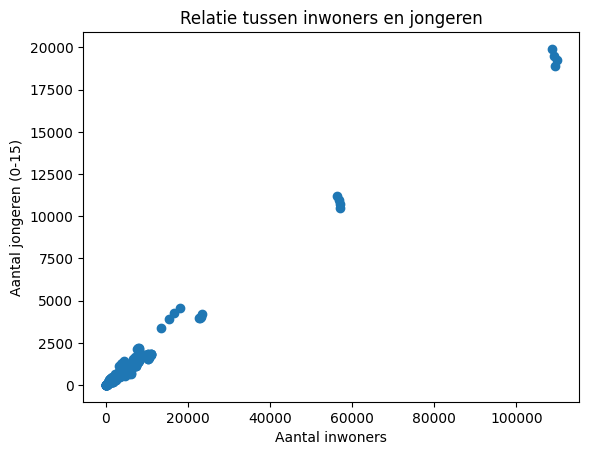

In [18]:
import matplotlib.pyplot as plt


plt.scatter(df["AantalInwoners_5"], df["k_0Tot15Jaar_8"])
plt.xlabel("Aantal inwoners")
plt.ylabel("Aantal jongeren (0-15)")
plt.title("Relatie tussen inwoners en jongeren")
plt.show()

Deze scatterplot toont de relatie tussen het aantal inwoners en het aantal jongeren (0–15 jaar) per wijk.
Elke punt in de grafiek vertegenwoordigt een wijk in een bepaald jaar.
De grafiek laat zien dat wijken met meer inwoners meestal ook meer jongeren hebben.

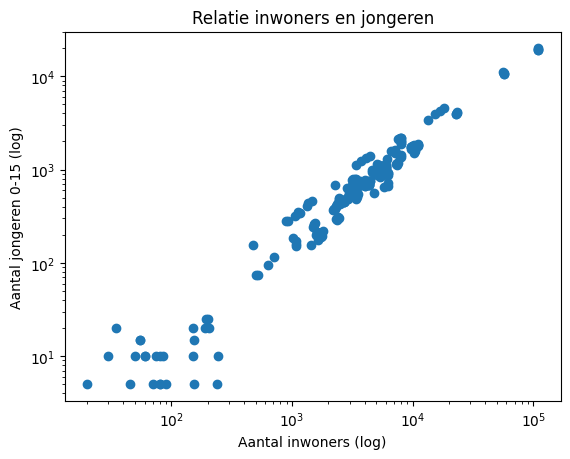

In [19]:
plt.scatter(df["AantalInwoners_5"], df["k_0Tot15Jaar_8"])
plt.xscale("log")
plt.yscale("log")

plt.xlabel("Aantal inwoners (log)")
plt.ylabel("Aantal jongeren 0-15 (log)")
plt.title("Relatie inwoners en jongeren")
plt.show()

Deze scatterplot toont dezelfde relatie tussen inwoners en jongeren, maar gebruikt een aangepaste schaal zodat verschillen beter zichtbaar worden. 

# Aantal jongeren per jaar, lijngrafiek

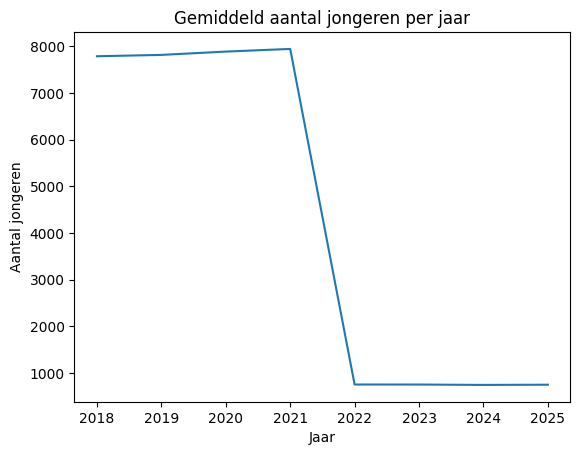

In [20]:
df.groupby("Jaar")["k_0Tot15Jaar_8"].mean().plot()

plt.title("Gemiddeld aantal jongeren per jaar")
plt.xlabel("Jaar")
plt.ylabel("Aantal jongeren")
plt.show()

Deze grafiek toont het gemiddelde aantal jongeren (0–15 jaar) per wijk per jaar. Hiermee kan worden gezien hoe het gemiddelde aantal jongeren zich over de jaren ontwikkelt.

Text(0, 0.5, 'aantal jongeren')

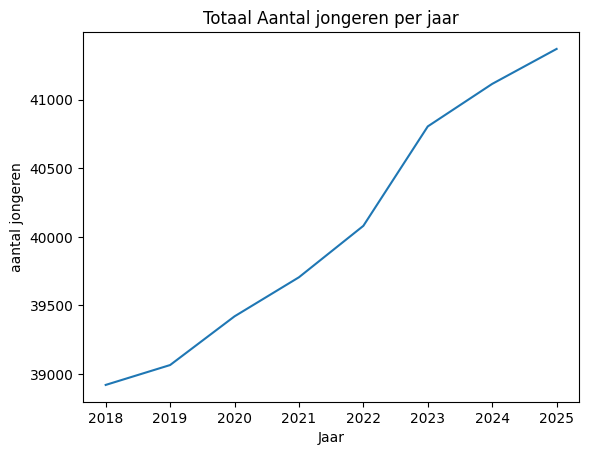

In [48]:
df.groupby("Jaar")["k_0Tot15Jaar_8"].sum().plot()

plt.title("Totaal Aantal jongeren per jaar")
plt.xlabel("Jaar")
plt.ylabel("aantal jongeren")

Deze grafiek toont het totale aantal jongeren (0–15 jaar) per jaar. In tegenstelling tot de vorige grafiek wordt hier niet het gemiddelde gebruikt, maar het totaal van alle wijken samen. Hierdoor wordt duidelijk hoe het totale aantal jongeren zich door de jaren heen ontwikkelt.

# Gemiddeld aantal inwoners per wijk, balkgrafiek

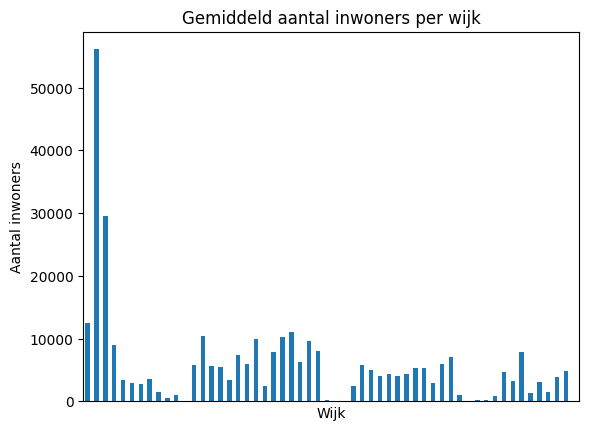

In [49]:
df.groupby("Wijk")["AantalInwoners_5"].mean().plot(kind="bar")

plt.title("Gemiddeld aantal inwoners per wijk")
plt.ylabel("Aantal inwoners")
plt.xticks([]) #verwijder x as labels anders is de balkgraf onleesbaar
plt.show()  

Deze balkgrafiek toont het gemiddelde aantal inwoners per wijk.
De grafiek laat zien dat er grote verschillen bestaan tussen de wijken.
Sommige wijken hebben aanzienlijk meer inwoners dan andere wijken.

# conclusie


De visualisaties geven een beter inzicht in de structuur van de dataset.
De grafieken tonen dat grotere wijken doorgaans ook meer jongeren bevatten en dat het totale aantal jongeren licht toeneemt over de jaren.
Daarnaast is zichtbaar dat het aantal inwoners sterk kan verschillen tussen verschillende wijken.